In [1]:
# ==========================================
# 1. MOUNT GOOGLE DRIVE
# ==========================================

from google.colab import drive
drive.mount('/content/drive')


# ==========================================
# 2. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ==========================================
# 3. LOAD DATASET FROM GOOGLE DRIVE
# ==========================================

file_path = "/content/drive/MyDrive/bank-data/bank-full.csv"

df = pd.read_csv(file_path, sep=";")


# Display dataset
print("Dataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())

Mounted at /content/drive
Dataset loaded successfully!

Dataset Shape:
(45211, 17)

First 5 rows:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [4]:
# ==========================================
# 4. CHECK DATASET
# ==========================================

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["y"].value_counts())


# ==========================================
# 5. SEPARATE FEATURES AND TARGET
# ==========================================

X = df.drop("y", axis=1)

y = df["y"].map({
    "yes": 1,
    "no": 0
})


# ==========================================
# 6. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ==========================================

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X.select_dtypes(
    include=["object"]
).columns


print("\nNumerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))


# ==========================================
# 7. PREPROCESSING
# ==========================================

numerical_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)


# ==========================================
# 8. TRAIN-TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


# ==========================================
# 9. LOGISTIC REGRESSION MODEL
# ==========================================

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# ==========================================
# 10. CREATE PIPELINE
# ==========================================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", logistic_model)
    ]
)


# ==========================================
# 11. TRAIN MODEL
# ==========================================

model.fit(X_train, y_train)

print("\nModel trained successfully!")


# ==========================================
# 12. MAKE PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)


# ==========================================
# 13. MODEL ACCURACY
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy * 100:.2f}%")


# ==========================================
# 14. CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No", "Yes"]
    )
)


# ==========================================
# 15. CONFUSION MATRIX
# ==========================================




Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Missing Values:
age          0
job          0
marital      0
education    0



Confusion Matrix:
[[7782  203]
 [ 690  368]]


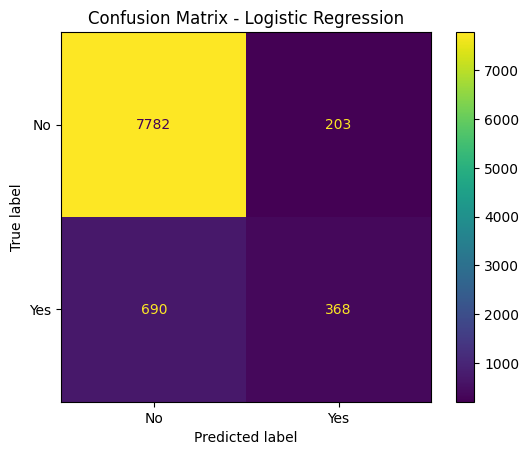

In [3]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ==========================================
# 16. VISUALIZE CONFUSION MATRIX
# ==========================================

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

display.plot()

plt.title("Confusion Matrix - Logistic Regression")

plt.show()